# Check below for visualization of skills learned per week from sampled students in "exp-static-flexible-anon-2025-05-29"

Loading data...
Dataset shape: (1893, 3)
Total unique students: 184
Week range: -2 to 8
Proficient score range: 0.0 to 26.0

Sampling 10 students...
Sampled 10 students:
 1. 104a9838c23bf4fc...
 2. 36b2f0b22e5e804d...
 3. d7edfa6ad5c3dcc0...
 4. a03a2ace27d448ae...
 5. d060596aa271cd49...
 6. 0d518d726a393090...
 7. 19cee7495589ae42...
 8. 56b5c3e5ba2594b4...
 9. a440592cf358ceb6...
10. 8afc5de46ea43d02...

Sample dataset shape: (106, 3)
Creating visualizations...


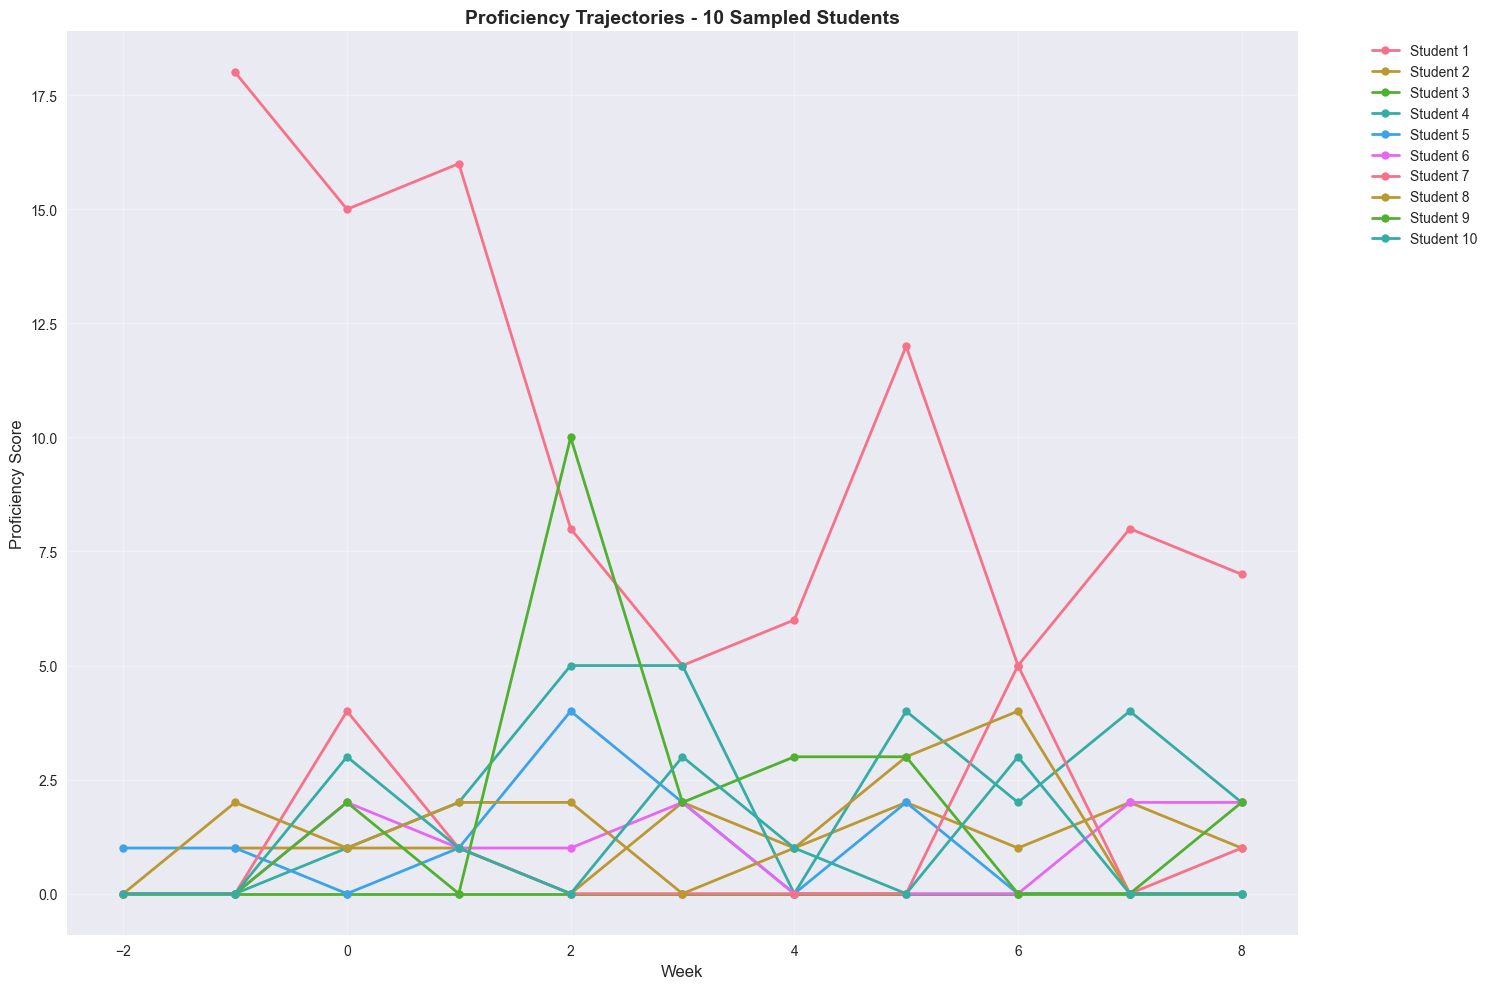

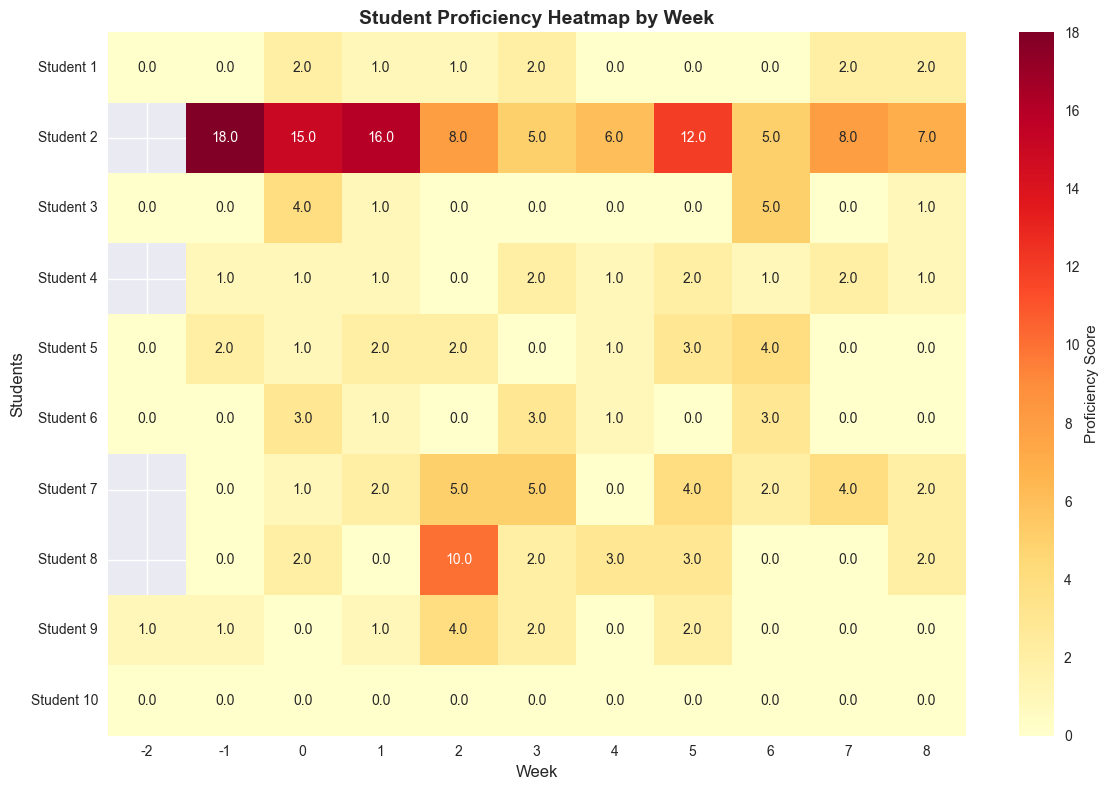


Summary Statistics for Sampled Students:
             mean   std  min   max  count
Student 1    0.91  0.94  0.0   2.0     11
Student 2   10.00  4.85  5.0  18.0     10
Student 3    1.00  1.79  0.0   5.0     11
Student 4    1.20  0.63  0.0   2.0     10
Student 5    1.36  1.36  0.0   4.0     11
Student 6    1.00  1.34  0.0   3.0     11
Student 7    2.50  1.90  0.0   5.0     10
Student 8    2.20  3.01  0.0  10.0     10
Student 9    1.00  1.26  0.0   4.0     11
Student 10   0.00  0.00  0.0   0.0     11

Overall Sample Statistics:
Average proficiency across all sampled data points: 2.05
Standard deviation: 3.33
Total data points: 106


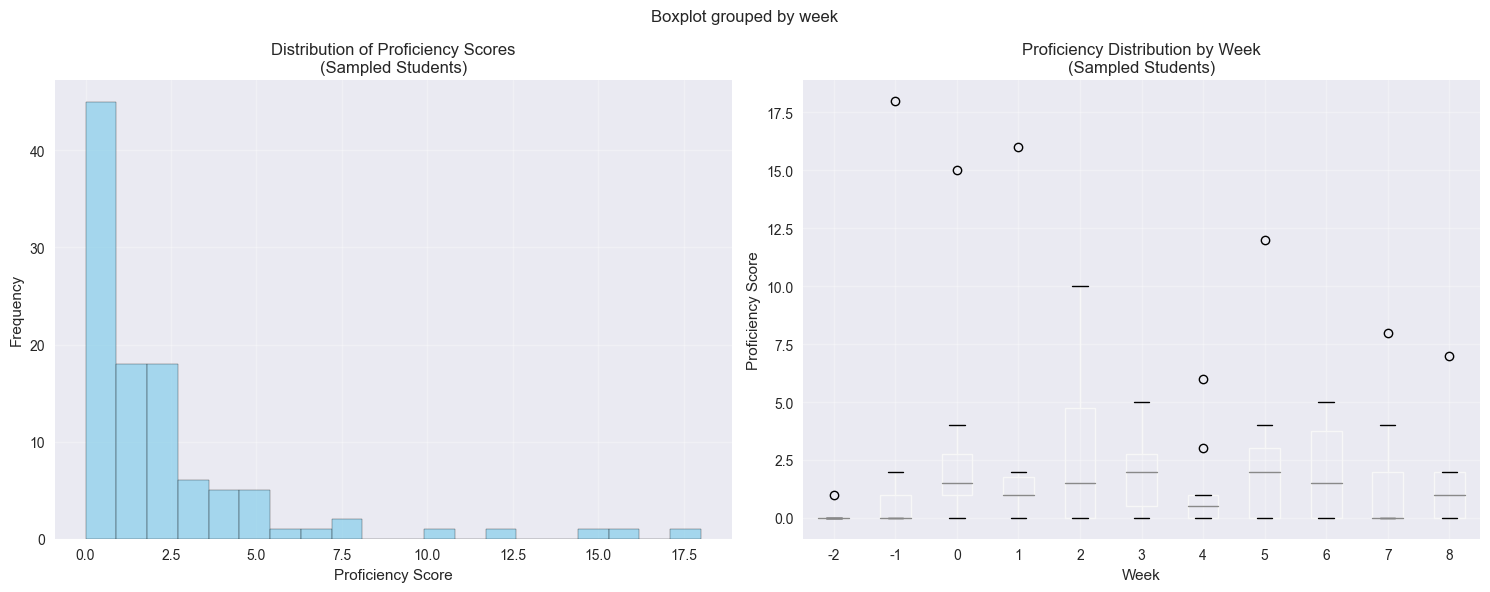

In [4]:
#!/usr/bin/env python3
"""
Student Proficiency Analysis - Sample of 10 Students

This script samples 10 random students from the dataset and visualizes 
their proficiency progression over time.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Loading data...")
# Load the data
df = pd.read_csv('~/cmu/goalsetting-recommendation-algorithm/time-series-predictor/data/data_tidied.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Total unique students: {df['name'].nunique()}")
print(f"Week range: {df['week'].min()} to {df['week'].max()}")
print(f"Proficient score range: {df['proficient'].min()} to {df['proficient'].max()}")

# Sample 10 random students
print("\nSampling 10 students...")
unique_students = df['name'].unique()
sampled_students = np.random.choice(unique_students, size=10, replace=False)

# Filter data for sampled students
sample_df = df[df['name'].isin(sampled_students)].copy()

print(f"Sampled {len(sampled_students)} students:")
for i, student in enumerate(sampled_students, 1):
    print(f"{i:2d}. {student[:16]}...")

print(f"\nSample dataset shape: {sample_df.shape}")

# Create visualizations
print("Creating visualizations...")

# 1. Individual proficiency trajectories plot
plt.figure(figsize=(15, 10))
for i, student in enumerate(sampled_students):
    student_data = sample_df[sample_df['name'] == student].sort_values('week')
    plt.plot(student_data['week'], student_data['proficient'], 
              marker='o', linewidth=2, markersize=6, 
              label=f'Student {i+1}')

plt.xlabel('Week', fontsize=12)
plt.ylabel('Proficiency Score', fontsize=12)
plt.title('Proficiency Trajectories - 10 Sampled Students', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Heatmap showing proficiency patterns
pivot_df = sample_df.pivot(index='name', columns='week', values='proficient')
student_labels = [f'Student {i+1}' for i in range(len(sampled_students))]
pivot_df.index = student_labels

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt='.1f', 
            cbar_kws={'label': 'Proficiency Score'})
plt.title('Student Proficiency Heatmap by Week', fontsize=14, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Students', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Summary statistics
print("\nSummary Statistics for Sampled Students:")
print("=" * 50)
summary_stats = sample_df.groupby('name')['proficient'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).round(2)
summary_stats.index = [f'Student {i+1}' for i in range(len(summary_stats))]
print(summary_stats)

print(f"\nOverall Sample Statistics:")
print(f"Average proficiency across all sampled data points: {sample_df['proficient'].mean():.2f}")
print(f"Standard deviation: {sample_df['proficient'].std():.2f}")
print(f"Total data points: {len(sample_df)}")

# 4. Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of proficiency scores
axes[0].hist(sample_df['proficient'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Proficiency Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Proficiency Scores\n(Sampled Students)')
axes[0].grid(True, alpha=0.3)

# Box plot by week
sample_df.boxplot(column='proficient', by='week', ax=axes[1])
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Proficiency Score')
axes[1].set_title('Proficiency Distribution by Week\n(Sampled Students)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()